In [1]:
import fasttext
from matplotlib import pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import torch
from torch import nn

# 1. Neural Nets

#### Dummy data

In [2]:
input_size = 1
output_size = 1

In [3]:
# Example dummy data for demonstration
X_train = torch.randn(100, input_size)
y_train = 2 * X_train + 1 + torch.randn(100, output_size) * 0.1 # y = 2x + 1 with noise

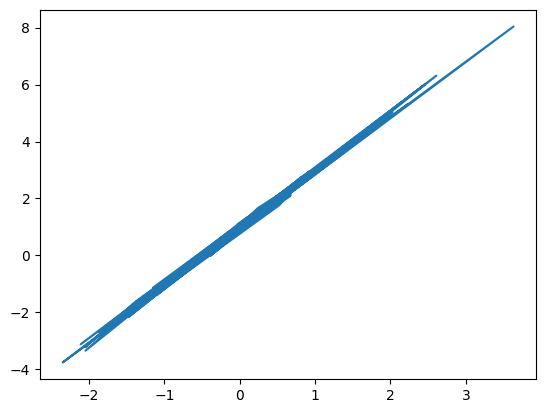

In [4]:
plt.plot(X_train, y_train)
plt.show()

#### Build Perceptron

In [5]:
class NNLinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        out = self.linear(x)
        return out

In [6]:
nn_lr_model = NNLinearRegressionModel(input_size, output_size)

In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(nn_lr_model.parameters(), lr=0.01) # Adjust learning rate as needed

In [8]:
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = nn_lr_model.forward(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    optimizer.zero_grad() # Clear previous gradients
    loss.backward()       # Compute gradients
    optimizer.step()      # Update weights

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.1223
Epoch [200/1000], Loss: 0.0119
Epoch [300/1000], Loss: 0.0106
Epoch [400/1000], Loss: 0.0106
Epoch [500/1000], Loss: 0.0106
Epoch [600/1000], Loss: 0.0106
Epoch [700/1000], Loss: 0.0106
Epoch [800/1000], Loss: 0.0106
Epoch [900/1000], Loss: 0.0106
Epoch [1000/1000], Loss: 0.0106


In [9]:
print("\nWeights and biases using model.named_parameters():")
for name, param in nn_lr_model.named_parameters():
    print(f"Layer: {name}, Data: {param.data}")


Weights and biases using model.named_parameters():
Layer: linear.weight, Data: tensor([[1.9992]])
Layer: linear.bias, Data: tensor([0.9791])


#### Compare with linear regression

In [10]:
lr = LinearRegression().fit(X_train, y_train)

In [11]:
lr.coef_

array([[1.9992403]], dtype=float32)

In [12]:
lr.intercept_

array([0.97909844], dtype=float32)